## Heart Diesease Prediction
In this project model will be trained using the actual Heart Disease dataset, so that we can predict whether a person has heart disease or not based on trained data.


In [27]:
import numpy as np
import pandas as pd
import pickle
import kagglehub
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow as mlflow


In [28]:
df = pd.read_csv('./heart.csv')

print(df.shape)
print(df.head())
print(df.info())

(1025, 14)
   age  sex  cp  trestbps  chol  fbs  ...  exang  oldpeak  slope  ca  thal  target
0   52    1   0       125   212    0  ...      0      1.0      2   2     3       0
1   53    1   0       140   203    1  ...      1      3.1      0   0     3       0
2   70    1   0       145   174    0  ...      1      2.6      0   0     3       0
3   61    1   0       148   203    0  ...      0      0.0      2   1     3       0
4   62    0   0       138   294    1  ...      0      1.9      1   3     2       0

[5 rows x 14 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thala

My observations from data:
* From the above data, what i observe is, 
* The data is having 1025 rows, 14 columns.
* Range of index for rows is 0 to 1024
* total 14 columns are there
* Dtype for oldpeak is float64 and for others it is int64.


In [29]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

### when i run df.isunull().sum() ---> result is 0 for all columns it means that "No Nulls, No actions needed."

In [30]:
class_value_counts = df['target'].value_counts()
print(class_value_counts)


target
1    526
0    499
Name: count, dtype: int64


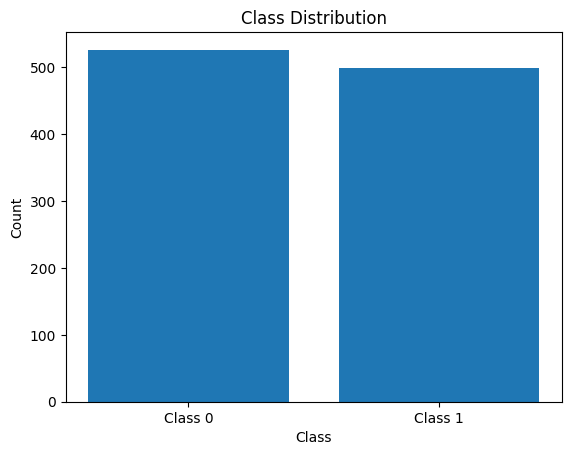

In [31]:
plt.bar(["Class 0", "Class 1"], class_value_counts.values)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()

### Observation from dataset:
The observation from value counts is that the dataset is balanced dataset. so the accuracy will give the right picture as there is no domination of particualr class. ROC_AUC value will give the confidence of how well the scoring more for positive sample and less for negative sample prediction.

array([[<Axes: title={'center': 'age'}>, <Axes: title={'center': 'sex'}>,
        <Axes: title={'center': 'cp'}>,
        <Axes: title={'center': 'trestbps'}>],
       [<Axes: title={'center': 'chol'}>,
        <Axes: title={'center': 'fbs'}>,
        <Axes: title={'center': 'restecg'}>,
        <Axes: title={'center': 'thalach'}>],
       [<Axes: title={'center': 'exang'}>,
        <Axes: title={'center': 'oldpeak'}>,
        <Axes: title={'center': 'slope'}>,
        <Axes: title={'center': 'ca'}>],
       [<Axes: title={'center': 'thal'}>,
        <Axes: title={'center': 'target'}>, <Axes: >, <Axes: >]],
      dtype=object)

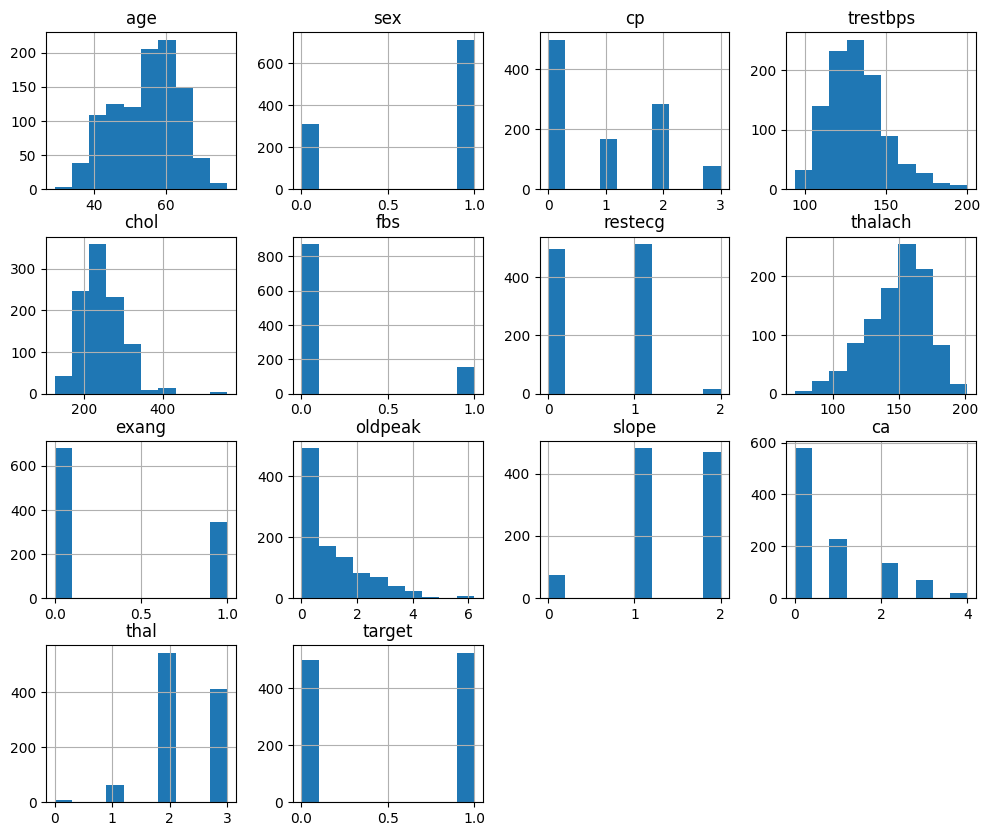

In [32]:
df.hist(figsize=(12, 10))

<Axes: >

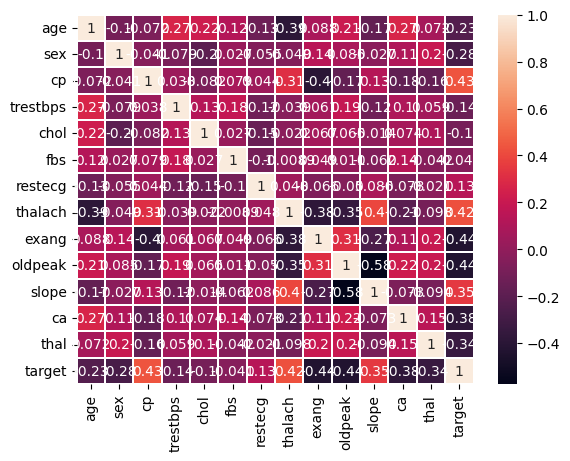

In [33]:
sns.heatmap(df.corr(), annot=True,linewidths=0.1)

co-related features: 
cp-target:0.43
cp-thalach:0.31
slope-thalach:0.4
thalach-target:0.42
oldpeak-exang:0.31
thal-exang:0.2
slope-target:

<Axes: >

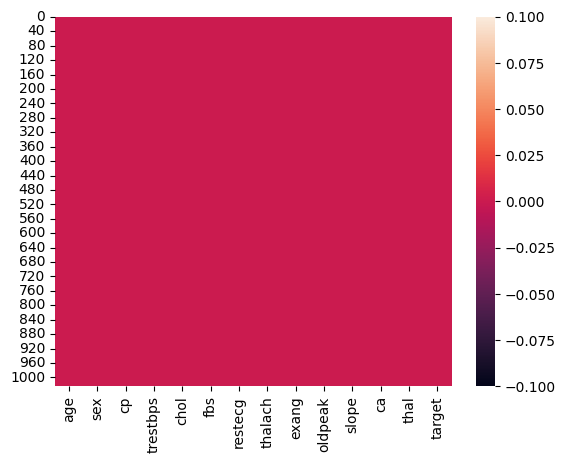

In [34]:
sns.heatmap(df.isnull())

In [35]:
categorical_features = ['cp', 'fbs', 'restecg', 'exang','sex']
numeric_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'slope', 'ca', 'thal']

X = df.drop('target', axis=1)
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy='mean')),
     ("scaler", StandardScaler())
])

#Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
     ("cat", OneHotEncoder(handle_unknown='ignore'))
])

#Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

#final pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(random_state=42))
])

### Summary:

For the model preprocessed data is ready. i.e., EDA is done, data is standardized, checked for if there are any null values, Now the data is ready for training.
There are total 13 features are there from which model should predict given the sample whether the sample contains heart disease or not.

In [36]:
mlflow.set_experiment('P1_Tabular_ML')

with mlflow.start_run(run_name='base_line'):

    mlflow.log_param('type', 'baseline')
    pipeline.fit(X_train, y_train)

    score = pipeline.score(X_test, y_test)

    mlflow.log_metric('accuracy', score)

    positive_scores = pipeline.predict_proba(X_test)[:,1]

    roc_auc = roc_auc_score(y_test, positive_scores)

    mlflow.log_metric('roc_auc', roc_auc)
    c = pipeline.named_steps['model'].C

    mlflow.log_param('c', c)

    solver = pipeline.named_steps['model'].solver
    mlflow.log_param('solver', solver)

Accuracy: 0.7853, As dataset is not a class-imbalance, accuracy makes sense, And accuracy means 78%, 78/100 times model answers correctly whether the given patient data has heart-disease or not.
Predict_Proba: the gives the output list where each list-item has two values, in which 0th-index will talk about negative probability and 1th-index will talk about positive probability. for example above,the first list item is [0.03272191 0.96727809], what it means is, for the given patient data, there is a chance of patient to be not having heart-disease is 0.03 (very less), and patient having heart-disease is 0.96, in which model is working fine. Model is working fine iam saying based on the probailities i got, the observation from probabilities is, model is giving probability of postive more, less for negative sample type.


accuracy is : 0.7853658536585366
roc_auc is :  0.8779744907671807
confusion matrix: 
 [[71 31]
 [13 90]]


d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


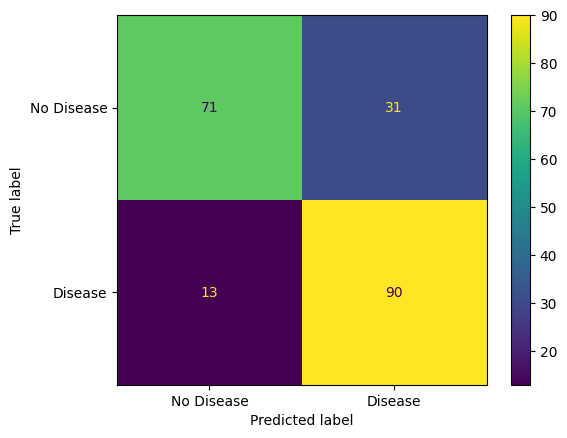

In [37]:
#model = LogisticRegression(penalty='l2',C=1.0)

model_l2 = Pipeline([('preprocessor', preprocessor),
                  ('model', LogisticRegression(penalty='l2', C=1.0))])
#C is the inverse of lamda, so to make the regularization stronger we need high lamda value, since c and lambda are inverse then, c will be lower

model_l2.fit(X_train, y_train)
y_pred_l2 = model_l2.predict(X_test)
#print(pred)

positive_scores = model_l2.predict_proba(X_test)[:,1]
#print(positive_scores)

score = model_l2.score(X_test, y_test)
roc_auc = roc_auc_score(y_test, positive_scores)

print(f'accuracy is : {score}')
print(f'roc_auc is :  {roc_auc}')

print('confusion matrix: \n', confusion_matrix(y_test, y_pred_l2))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_l2, display_labels=['No Disease', 'Disease'])



From the printed confusion matrix, the 2x2 matrix, each position will tell us about the predictions and what the actual values are,
[0, 0] - says the TN-  which means true value is negative (patient is healthy) and predicted value also negative (patient is healthy)
[0, 1] - says about FP - which means true value is negative (patient is healthy) but predicted value is positive (patient is sick)
[1, 0] - says about FN - which means true value is positive (patient is sick) but predicted value is negative (patient is healthy)
[1, 1] - says that TP - which means true value is positive (patient is sick) but predicted value is positive (patient is sick)

Look for the above confusion matrix display for better understanding of confusion matrix.

FN - 13, which means that model predicted 13 patients as healthy but true value of the patient is sick.
so model missed 13 patients.

Why is FN the scariest number in a medical screening?
- The FN is scariest number in a medical screeening because False negative means the model is telling that patient is healthy, but
in real world the patient is sick, in medical engineering you can not declare the sick patient as healthy as it will cost lives of
the patient, which will totally violates the true meaning of medical engineering.

For the Logistic regression l2, 
Accuracy is : 0.78536585
Roc_auc is : 0.879497430

0.7902439024390244
0.8756900818579858
[[71 31]
 [12 91]]


d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


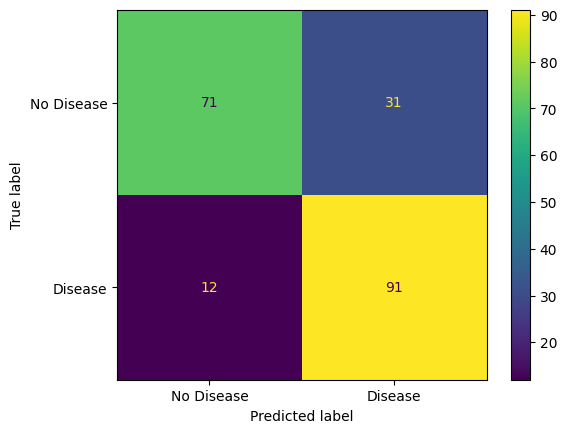

In [38]:
#model = LogisticRegression(penalty='l1',solver='liblinear')

model_l1 = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression('l1', C=1.0, solver='liblinear', random_state=42))])
model_l1.fit(X_train, y_train)

y_pred_l1 = model_l1.predict(X_test)

positive_scores = model_l1.predict_proba(X_test)[:,1]

score = model_l1.score(X_test, y_test)
roc_auc = roc_auc_score(y_test, positive_scores)


print(score)
print(roc_auc)


print(confusion_matrix(y_test, y_pred_l1))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_l1, display_labels=['No Disease', 'Disease'])


From the confusion matrix of L1 regression,
The FN - 12,
Which means that model is predicting 12 patients as healthy, even if they are sick.

So when i compare FN of L1 with FN of L2, FN-L1 is better which means L1 will give better predictions when you compare them with L2.

L1 needs special solver, for the following reason.
In L2 regression what happens is that, L2 regression adds penalty to the features in such a way that the features contribution to the will become near to zero but not exactly to zero. In L1 regression, the feature selection also happens which means that, some features can be irrevelant to final predictions so such features can be eliminated via L1 regression.

features order in the dataset: 
age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope ca thal target
coef from lasso regression:
[[ 0.01176484 -1.68241069  0.83702718 -0.01571873 -0.00830205 -0.11553265
   0.28308643  0.03479359 -0.77018851 -0.64140801  0.54948541 -0.80639537
  -1.01440171]]

Lasso regression helps in such a way that, lasso regression eleminates some features so that the prediction will become more accurate and does not deviate the actual predictions.

nearly 4 feature went near to zero.
For the Logistic regression l1, 
Accuracy is : 0.78536585
Roc_auc is : 0.878450409

In [14]:

scores = cross_validate(model_l2, X_train, y_train, cv=5, scoring=['precision','roc_auc'])

print(scores)
#cross-validation reduces variance of the dataset so that the predictions becomes accurate. As learned earlier, the bias and variance
#are inversly proportional like, if you increase bias (The line should not have to touch all the points) but when you are doing the
#predictions it will reduce the variance between the datset and will get better predictions

mean_precision = np.mean(scores['test_precision'])
std_precision = np.std(scores['test_precision'])

mean_roc_auc = np.mean(scores['test_roc_auc'])
std_roc_auc = np.std(scores['test_roc_auc'])

mean_fit_time = np.mean(scores['fit_time'])
std_fit_time = np.std(scores['fit_time'])

mean_score_time = np.mean(scores['score_time'])
std_score_time = np.std(scores['score_time'])

print(f'mean precision : {mean_precision}, std precision: {std_precision}')
print(f'mean roc auc : {mean_roc_auc}, std roc_auc: {std_roc_auc}')
print(f'mean fit_time : {mean_fit_time}, std fit_time: {std_fit_time}')
print(f'mean score_time : {mean_score_time}, std score_time: {std_score_time}')


d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warn

{'fit_time': array([0.02880383, 0.02615929, 0.02300525, 0.02271414, 0.02333856]), 'score_time': array([0.01866841, 0.018399  , 0.01697707, 0.02093029, 0.01743984]), 'test_precision': array([0.8255814 , 0.8125    , 0.87356322, 0.86021505, 0.76530612]), 'test_roc_auc': array([0.93363095, 0.915625  , 0.93268801, 0.94743112, 0.87550261])}
mean precision : 0.8274331579904125, std precision: 0.038180707014489265
mean roc auc : 0.9209755389497571, std roc_auc: 0.024874305615725564
mean fit_time : 0.024804210662841795, std fit_time: 0.0023488705620081144
mean score_time : 0.01848292350769043, std score_time: 0.0013701577586482916


d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


CV makes the predictions very much reliable because when you divide the dataset into folds each will be act as a test dataset. So while training only you are making sure that the model is getting predicted over the test dataset.

In [15]:
scores = cross_validate(model_l1, X_train, y_train, cv=5, scoring=['precision', 'roc_auc'])

print(scores)

mean_precision = np.mean(scores['test_precision'])
std_precision = np.std(scores['test_precision'])

mean_roc_auc = np.mean(scores['test_roc_auc'])
std_roc_auc = np.std(scores['test_roc_auc'])

mean_fit_time = np.mean(scores['fit_time'])
std_fit_time = np.std(scores['fit_time'])

mean_score_time = np.mean(scores['score_time'])
std_score_time = np.std(scores['score_time'])

print(f'mean precision : {mean_precision}, std precision: {std_precision}')
print(f'mean roc auc : {mean_roc_auc}, std roc_auc: {std_roc_auc}')
print(f'mean fit_time : {mean_fit_time}, std fit_time: {std_fit_time}')
print(f'mean score_time : {mean_score_time}, std score_time: {std_score_time}')

d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of pen

{'fit_time': array([0.0196197 , 0.01544118, 0.01705289, 0.0172987 , 0.01563811]), 'score_time': array([0.01793766, 0.01809978, 0.01709509, 0.01503921, 0.01700974]), 'test_precision': array([0.8255814 , 0.80208333, 0.87356322, 0.86021505, 0.76530612]), 'test_roc_auc': array([0.93377976, 0.91696429, 0.93313477, 0.94698436, 0.87386448])}
mean precision : 0.8253498246570791, std precision: 0.039209042207941004
mean roc auc : 0.9209455332766018, std roc_auc: 0.025392090633112503
mean fit_time : 0.01701011657714844, std fit_time: 0.0014992671403787575
mean score_time : 0.017036294937133788, std score_time: 0.0010895869256250838


High mean & High std tells you what?
- Im answering in the perspective of Precision, lets suppose if you are considering for precision, High precision mean is always good in the case of k-fold cv as the verification is done across the training dataset. and high std is not good in the perspective of precision because high std tells you that, how much precision is changing from the mean of the precision for each fold, each fold deviation is not changing much from the mean precision then you can say that, you can rely on the precision and it will generalize the precision well across the training dataset.

In [16]:
with mlflow.start_run(run_name='l2_model'):
    mlflow.log_param('type', 'l2_model')

    l2_model = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(penalty='l2', C=1.0))])
    l2_scores = cross_validate(l2_model, X_train, y_train, cv=5, scoring=['precision','roc_auc'])
    mlflow.log_param('l2_c', 1.0)
    mlflow.log_param('l2_solver', 'lbfgs')
    mlflow.log_metric('l2_precision', np.mean(l2_scores['test_precision']))
    mlflow.log_metric('l2_std_precision', np.std(l2_scores['test_precision']))
    mlflow.log_metric('l2_roc_auc', np.mean(l2_scores['test_roc_auc']))
    mlflow.log_metric('l2_std_roc_auc', np.std(l2_scores['test_roc_auc']))


with mlflow.start_run(run_name='l1_model'):
    mlflow.log_param('type', 'l1_model')
    l1_model = Pipeline([('preprocessor', preprocessor), ('model', LogisticRegression(penalty='l1', C=1.0, solver='liblinear'))])
    l1_scores = cross_validate(l1_model, X_train, y_train, cv=5, scoring=['roc_auc', 'precision'])
    mlflow.log_param('l1_c', 1.0)
    mlflow.log_param('l1_solver', 'liblinear')
    mlflow.log_metric('l1_precision', np.mean(l1_scores['test_precision']))
    mlflow.log_metric('l1_std_precision', np.std(l1_scores['test_precision']))
    mlflow.log_metric('l1_roc_auc', np.mean(l1_scores['test_roc_auc']))
    mlflow.log_metric('l1_std_roc_auc', np.std(l1_scores['test_roc_auc']))

d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\ai-engineering-journey\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warn

As from the mlflow ui, l1_precision is 0.83535 and l2_precision is 0.83743, l1_precision is slightly more. and std for l1 and l2 is 0.03357 and 0.03342. here also l2_std is less which l2 is more precise as per the numbers.

It is very important to take the more precision and less standard deviation model as this is for heart disease model which is very important to be more precisie because if we lose one sick patient it will have impact on the patient life which is very critical.

In [41]:
print(classification_report(y_test,y_pred_l2, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.85      0.70      0.76       102
     Disease       0.74      0.87      0.80       103

    accuracy                           0.79       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.79      0.78       205



In [42]:
print(classification_report(y_test, y_pred_l1, target_names=['No Disease', 'Disease']))

              precision    recall  f1-score   support

  No Disease       0.86      0.70      0.77       102
     Disease       0.75      0.88      0.81       103

    accuracy                           0.79       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.79      0.79       205



| Model | Precision | Recall | F1   |
|-------|-----------|--------|------|
| L2    | 0.74      | 0.87   | 0.80 |
| L1    | 0.75      | 0.88   | 0.81 |   

From the above table it is clear that:

For L2:
* Recall: 0.87 means, L2 model catches 87% of actual Positive samples
* Precision: 0.74 means, If L2 model says sample is positive, it means 74% of the times it will be positive.

For L1:
* Recall: 0.88 means, L1 model catches 88% of actual Positive samples
* Precision: 0.75 means,If L1 model says sample is positive, it means 75% of the times it will be positive

For heart disease screening, Recall protects more because, Recall will make sure that we are not missing any sick patient.

With the current understanding, Recall is important because missing sick patient will cost the patient lives. and at the same time precision also important to make sure that predicted disease sample is actually having disease.